# Matching

The goal is to do two sets of Matching.

- **Intent to Treat Matching**: Match those who were admitted to the program (Non-Graduates AND Graduates) and match them against those who did NOT attend the Program (Interviewed and Non-TIP)
- **Treatment Matching**: Match those who graduated from the program against those that did not graduate from the program.

We will Match to determine:
- TIP's affect on Income Earnings
- TIP's affect on Employment
- TIP's affect on Criminal Justice Interactions
- TIP's affect on Recidivism

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm

In [2]:
tip_students = pd.read_csv('TIP_StudentData.csv', parse_dates=['DOB', 'GraduatedDate', 'StartDate', 'EndDate', 'InterviewedDate', 'CreatedDate'])

In [3]:
tip_clean = pd.read_csv('TIP_Clean.csv', parse_dates = ['CreatedDate', 'DoB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date'])

In [4]:
tip_clean_mod = tip_clean.rename(columns={
    'participant_id': 'tip_id',
    'DoB': 'DOB', 
    'status': 'tip_status',
})

common_cols = [col for col in tip_clean_mod.columns if col in tip_students.columns and col != 'tip_id']
tip_clean_unique = tip_clean_mod.drop(columns=common_cols)

all_tip_students = pd.merge(tip_students, tip_clean_unique, on='tip_id', how='outer')

In [5]:
# define status
def status(row):
    if not pd.isnull(row['GraduatedDate']):
        return 'Graduated'
    elif (not pd.isnull(row['StartDate'])) & (not pd.isnull(row['EndDate'])) & ((row['EndDate'] - row['StartDate']).days < 120):
        return 'Non Graduated'
    elif (not pd.isnull(row['InterviewedDate'])) & ((pd.isnull(row['EndDate'])) or (row['EndDate'] - row['InterviewedDate']).days < 120):
        return 'Interviewed'
    else:
        return 'None'
    
all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
Graduated        759
Non Graduated    723
None             691
Interviewed      550
Name: count, dtype: int64

In [ ]:
# Load data
df_student = all_tip_students.copy()

date_cols = ['DOB', 'StartDate', 'EndDate', 'GraduatedDate', 'InterviewedDate']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors='coerce')

# pre/post 2022 cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 2, 1),
    np.nan
)
df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors="coerce")


# Demographics
tip_demo = pd.read_csv('tip_cohort_demographics_rg.csv')[['tip_id', 'gender', 'race', 'census_tract']]
tip_demo['tip_id'] = pd.to_numeric(tip_demo['tip_id'], errors='coerce')

df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demo,
    on='tip_id',
    how='left'
)

# Age at start + age band
df_student['age_at_start'] = np.where(
    df_student['StartDate'].notna() & df_student['DOB'].notna(),
    (df_student['StartDate'] - df_student['DOB']).dt.days // 365,
    np.nan
)

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['age_at_start'].apply(assign_age_band)

# Sentencing data
tip_sentencing = pd.read_csv(
    'TIP_MergedSentencingData.csv',
    parse_dates=['DOB', 'DOS', 'StartDate']
)

tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB']).dt.days // 365
)

In [7]:
# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

# Arrest data
tip_arrests = pd.read_csv(
    'arrest_data.csv',
    parse_dates=['ArrestDate', 'StartDate']
)

tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()


In [8]:
# Earnings data
tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')

tip_earnings['tip_id'] = pd.to_numeric(tip_earnings['tip_id'], errors='coerce')
tip_earnings['quarter'] = tip_earnings['quarter'].astype(str)

tip_earnings['year'] = pd.to_numeric(tip_earnings['quarter'].str[:4], errors='coerce')
tip_earnings['q_num'] = pd.to_numeric(tip_earnings['quarter'].str[-1], errors='coerce')

quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
tip_earnings['quarter_label'] = tip_earnings['q_num'].replace(quarter_map)

tip_earnings['year_quarter'] = (
    tip_earnings['year'].astype('Int64').astype(str) + '-' + tip_earnings['quarter_label']
)
tip_earnings['year_quarter_dt'] = pd.PeriodIndex(
    tip_earnings['year_quarter'],
    freq='Q'
).to_timestamp()

tip_earnings = tip_earnings.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (
    (tip_earnings['year_quarter_dt'] - tip_earnings['DOB']).dt.days // 365
)

# keep non-missing earnings, but DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

# earnings one year prior: quarters -4 to -1
earnings_1yr_prior = tip_earnings[
    tip_earnings['quarters_from_start'].between(-4, -1)
].groupby('tip_id')['earnings'].sum().reset_index(name='earnings_year_prior')

# earnings two years prior: quarters -8 to -1
earnings_2yr_prior = tip_earnings[
    tip_earnings['quarters_from_start'].between(-8, -1)
].groupby('tip_id')['earnings'].sum().reset_index(name='earnings_two_years_prior')

# employment right before TIP: any positive earnings in quarter -1
job_right_before = tip_earnings[
    tip_earnings['quarters_from_start'] == -1
].groupby('tip_id')['earnings'].apply(lambda x: 1 if (x > 0).any() else 0).reset_index(name='job_right_before_tip')

C:\Users\13429\AppData\Local\Temp\ipykernel_25568\3426312630.py:2: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')


In [9]:
# Build TIP baseline summary table
tip_base = df_student.copy()

tip_base = tip_base.merge(sent_summary, on='tip_id', how='left')
tip_base = tip_base.merge(arrest_summary, on='tip_id', how='left')
tip_base = tip_base.merge(earnings_1yr_prior, on='tip_id', how='left')
tip_base = tip_base.merge(earnings_2yr_prior, on='tip_id', how='left')
tip_base = tip_base.merge(job_right_before, on='tip_id', how='left')

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in tip_base.columns:
        tip_base[col] = tip_base[col].fillna(0)

print("tip_base shape:", tip_base.shape)
print("\nTIP missingness summary:")
print(
    tip_base[
        [
            'tip_id', 'DOB', 'StartDate', 'Status', 'cohort_2022',
            'age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_year_prior', 'earnings_two_years_prior',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

tip_base shape: (2723, 43)

TIP missingness summary:
tip_id                           0
DOB                            416
StartDate                     1141
Status                           0
cohort_2022                   1141
age_at_start                  1141
age_band                      1141
gender                         533
race                           546
census_tract                   546
num_sentences_before_start       0
any_sentence_before_start        0
max_ogs_before_start             0
any_high_ogs_before_start        0
num_arrests_before_start         0
any_arrest_before_start          0
earnings_year_prior              0
earnings_two_years_prior         0
job_right_before_tip             0
dtype: int64


## PCS

In [10]:
# Load and clean PCS sentencing data
pcs_raw = pd.read_csv(
    'full_pcs.txt',
    parse_dates=['DOB', 'DOF', 'DOS']
)

pcs_raw['PCS_OFF_ID'] = pd.to_numeric(pcs_raw['PCS_OFF_ID'], errors='coerce')
pcs_raw['age_at_sentencing'] = (
    (pcs_raw['DOS'] - pcs_raw['DOB']).dt.days // 365
)

pcs_raw = pcs_raw[
    pcs_raw['PCS_OFF_ID'].notna() &
    pcs_raw['DOB'].notna()
].copy()

pcs_raw = pcs_raw[
    pcs_raw['age_at_sentencing'].isna() |
    ((pcs_raw['age_at_sentencing'] > 15) & (pcs_raw['age_at_sentencing'] < 59))
].copy()

pcs_raw['PCS_OFF_ID'] = pcs_raw['PCS_OFF_ID'].astype(int)

print("pcs_raw shape:", pcs_raw.shape)

# Build PCS sentencing summary
pcs_sent_summary = pcs_raw.groupby('PCS_OFF_ID').agg(
    num_sentences_total=('DOS', 'count'),
    any_sentence_record=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing=('age_at_sentencing', 'min'),
    max_ogs=('OGS', 'max'),
    any_high_ogs=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

C:\Users\13429\AppData\Local\Temp\ipykernel_25568\475452987.py:2: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_raw = pd.read_csv(


pcs_raw shape: (2555720, 9)


KeyboardInterrupt: 

In [ ]:
# Load and clean PCS earnings data
pcs_earnings = pd.read_csv('ui_earnings.txt')

pcs_earnings = pcs_earnings.dropna(subset=['pcs_off_id']).copy()
pcs_earnings['PCS_OFF_ID'] = pd.to_numeric(pcs_earnings['pcs_off_id'], errors='coerce')
pcs_earnings = pcs_earnings[pcs_earnings['PCS_OFF_ID'].notna()].copy()
pcs_earnings['PCS_OFF_ID'] = pcs_earnings['PCS_OFF_ID'].astype(int)

pcs_earnings['quarter'] = pcs_earnings['quarter'].astype(str)
pcs_earnings['year'] = pd.to_numeric(pcs_earnings['quarter'].str[:4], errors='coerce')
pcs_earnings['q_num'] = pd.to_numeric(pcs_earnings['quarter'].str[-1], errors='coerce')

quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
pcs_earnings['quarter_label'] = pcs_earnings['q_num'].replace(quarter_map)

pcs_earnings['year_quarter'] = (
    pcs_earnings['year'].astype('Int64').astype(str) + '-' + pcs_earnings['quarter_label']
)
pcs_earnings['year_quarter_dt'] = pd.PeriodIndex(
    pcs_earnings['year_quarter'],
    freq='Q'
).to_timestamp()

pcs_dob = pcs_raw[['PCS_OFF_ID', 'DOB']].drop_duplicates()

pcs_earnings = pcs_earnings.merge(
    pcs_dob,
    on='PCS_OFF_ID',
    how='left'
)

pcs_earnings['age'] = (
    (pcs_earnings['year_quarter_dt'] - pcs_earnings['DOB']).dt.days // 365
)

pcs_earnings = pcs_earnings.dropna(subset=['earnings']).copy()

pcs_earnings = pcs_earnings[
    pcs_earnings['age'].isna() |
    ((pcs_earnings['age'] > 15) & (pcs_earnings['age'] < 59))
].copy()

print("pcs_earnings shape:", pcs_earnings.shape)

# Build PCS earnings summary
pcs_earnings_summary = pcs_earnings.groupby('PCS_OFF_ID').agg(
    earnings_total=('earnings', 'sum'),
    earnings_mean=('earnings', 'mean'),
    earnings_median=('earnings', 'median'),
    any_positive_earnings=('earnings', lambda x: 1 if (x > 0).any() else 0)
).reset_index()

pcs_earnings_age_summary = pcs_earnings.groupby('PCS_OFF_ID').agg(
    min_age_with_earnings=('age', 'min'),
    max_age_with_earnings=('age', 'max')
).reset_index()

# Load PCS demographics
pcs_demo = pd.read_csv('DHS_demographics.csv')[['pcs_off_id', 'gender', 'race', 'census_tract']]

pcs_demo = pcs_demo.dropna(subset=['pcs_off_id']).copy()
pcs_demo['PCS_OFF_ID'] = pd.to_numeric(pcs_demo['pcs_off_id'], errors='coerce')
pcs_demo = pcs_demo[pcs_demo['PCS_OFF_ID'].notna()].copy()
pcs_demo['PCS_OFF_ID'] = pcs_demo['PCS_OFF_ID'].astype(int)

pcs_demo = pcs_demo.drop(columns=['pcs_off_id'])

C:\Users\13429\AppData\Local\Temp\ipykernel_10504\2930035392.py:2: DtypeWarning: Columns (2,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_earnings = pd.read_csv('ui_earnings.txt')


pcs_earnings shape: (2861593, 19)


In [ ]:
# Build PCS baseline table
pcs_base = pcs_raw[['PCS_OFF_ID', 'DOB']].drop_duplicates().copy()

pcs_base = pcs_base.merge(pcs_sent_summary, on='PCS_OFF_ID', how='left')
pcs_base = pcs_base.merge(pcs_earnings_summary, on='PCS_OFF_ID', how='left')
pcs_base = pcs_base.merge(pcs_earnings_age_summary, on='PCS_OFF_ID', how='left')
pcs_base = pcs_base.merge(pcs_demo, on='PCS_OFF_ID', how='left')

pcs_fill_zero_cols = [
    'num_sentences_total',
    'any_sentence_record',
    'max_ogs',
    'any_high_ogs',
    'earnings_total',
    'earnings_mean',
    'earnings_median',
    'any_positive_earnings'
]

for col in pcs_fill_zero_cols:
    if col in pcs_base.columns:
        pcs_base[col] = pcs_base[col].fillna(0)

pcs_base = pcs_base.drop_duplicates().reset_index(drop=True)

print("pcs_base shape:", pcs_base.shape)
print("\nPCS missingness summary:")
print(
    pcs_base[
        [
            'PCS_OFF_ID', 'DOB', 'gender', 'race', 'census_tract',
            'num_sentences_total', 'any_sentence_record',
            'min_age_at_sentencing', 'max_ogs', 'any_high_ogs',
            'earnings_total', 'earnings_mean', 'earnings_median',
            'any_positive_earnings',
            'min_age_with_earnings', 'max_age_with_earnings'
        ]
    ].isna().sum()
)

pcs_base shape: (1091004, 16)

PCS missingness summary:
PCS_OFF_ID                    0
DOB                           0
gender                   968009
race                     970416
census_tract             972169
num_sentences_total           0
any_sentence_record           0
min_age_at_sentencing         0
max_ogs                       0
any_high_ogs                  0
earnings_total                0
earnings_mean                 0
earnings_median               0
any_positive_earnings         0
min_age_with_earnings    991106
max_age_with_earnings    991106
dtype: int64


## Graduate vs. Non-Graduate Analysis File

This section constructs the analysis dataset for comparing TIP graduates with non-graduates.  
At this stage, we are not yet performing the final matching or regression. Instead, we define the treatment group, assemble baseline covariates measured before TIP start, and create post-TIP outcome variables.

We define:

- **Treatment group**: Graduated participants
- **Control group**: Non-Graduated participants

We focus on the following outcomes within 1.5 years after TIP start:

- \(Y_e\): any employment
- \(Y_w\): total earnings
- \(Y_o\): any offense
- \(Y_a\): any arrest

The baseline covariates are measured before TIP start and include demographics, cohort, age band, prior justice involvement, and prior earnings history. These variables will later be used for sample diagnostics, matching, and regression adjustment.

In [11]:
# 1. Start from the cleaned TIP baseline table
grad_non_grad = tip_base.copy()

# Keep only Graduated and Non Graduated participants
grad_non_grad = grad_non_grad[
    grad_non_grad['Status'].isin(['Graduated', 'Non Graduated'])
].copy()

# Apply the study cutoff used in the original notebook
grad_non_grad = grad_non_grad[
    grad_non_grad['StartDate'] < pd.Timestamp('2024-06-01')
].copy()

# Define treatment
grad_non_grad['treatment'] = np.where(
    grad_non_grad['Status'] == 'Graduated',
    1,
    0
)

# Keep plausible adult ages
grad_non_grad = grad_non_grad[
    grad_non_grad['age_at_start'].notna() &
    (grad_non_grad['age_at_start'] > 15)
].copy()

# Clean demographic display values
grad_non_grad['race'] = grad_non_grad['race'].fillna('Unknown').replace(0, 'Unknown')
grad_non_grad['gender'] = grad_non_grad['gender'].fillna('Unknown').replace(0, 'Unknown')

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].where(
    grad_non_grad['census_tract'].notna(),
    'Unknown'
)

# Optional: if census_tract is numeric, convert non-missing values to int-like string
grad_non_grad['census_tract'] = grad_non_grad['census_tract'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else str(int(x))
)

In [12]:
# 2. Build post-TIP timing variables

# Sentencing years since TIP
tip_sentencing_analysis = tip_sentencing.copy()
tip_sentencing_analysis = tip_sentencing_analysis.merge(
    tip_base[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left',
    suffixes=('', '_base')
)

if 'StartDate_base' in tip_sentencing_analysis.columns:
    tip_sentencing_analysis['StartDate'] = tip_sentencing_analysis['StartDate_base'].combine_first(
        tip_sentencing_analysis['StartDate']
    )
    tip_sentencing_analysis = tip_sentencing_analysis.drop(columns=['StartDate_base'])

tip_sentencing_analysis['YearsSinceTIP'] = (
    (tip_sentencing_analysis['DOS'] - tip_sentencing_analysis['StartDate']).dt.days / 365.25
)

# Arrest years since TIP
tip_arrests_analysis = tip_arrests.copy()
tip_arrests_analysis = tip_arrests_analysis.merge(
    tip_base[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left',
    suffixes=('', '_base')
)

if 'StartDate_base' in tip_arrests_analysis.columns:
    tip_arrests_analysis['StartDate'] = tip_arrests_analysis['StartDate_base'].combine_first(
        tip_arrests_analysis['StartDate']
    )
    tip_arrests_analysis = tip_arrests_analysis.drop(columns=['StartDate_base'])

tip_arrests_analysis['YearsSinceTIP'] = (
    (tip_arrests_analysis['ArrestDate'] - tip_arrests_analysis['StartDate']).dt.days / 365.25
)

# Earnings years since TIP
tip_earnings_analysis = tip_earnings.copy()

if 'StartDate' not in tip_earnings_analysis.columns:
    tip_earnings_analysis = tip_earnings_analysis.merge(
        tip_base[['tip_id', 'StartDate']].drop_duplicates(),
        on='tip_id',
        how='left'
    )

tip_earnings_analysis['YearsSinceTIP'] = (
    (tip_earnings_analysis['year_quarter_dt'] - tip_earnings_analysis['StartDate']).dt.days / 365.25
)

In [13]:
# 3. Construct post-TIP outcomes within 1.5 years

# Employment outcome: any positive earnings within 1.5 years after TIP start
employment_outcome = (
    tip_earnings_analysis[
        (tip_earnings_analysis['YearsSinceTIP'] > 0) &
        (tip_earnings_analysis['YearsSinceTIP'] < 1.5) &
        (tip_earnings_analysis['earnings'] > 0)
    ]
    .groupby('tip_id')
    .agg(
        employment_outcome=('earnings', lambda x: 1),
        employment_outcome_earnings=('earnings', 'sum')
    )
    .reset_index()
)

# Offense outcome: any sentencing record within 1.5 years after TIP start
offense_outcome = (
    tip_sentencing_analysis[
        (tip_sentencing_analysis['YearsSinceTIP'] > 0) &
        (tip_sentencing_analysis['YearsSinceTIP'] < 1.5)
    ]
    .groupby('tip_id')
    .size()
    .reset_index(name='offense_count_post_1_5y')
)

offense_outcome['offense_outcome'] = 1

# Arrest outcome: any arrest within 1.5 years after TIP start
arrest_outcome = (
    tip_arrests_analysis[
        (tip_arrests_analysis['YearsSinceTIP'] > 0) &
        (tip_arrests_analysis['YearsSinceTIP'] < 1.5)
    ]
    .groupby('tip_id')
    .size()
    .reset_index(name='arrest_count_post_1_5y')
)

arrest_outcome['arrest_outcome'] = 1

In [14]:
# 4. Merge outcomes into analysis file
grad_non_grad = grad_non_grad.merge(
    employment_outcome,
    on='tip_id',
    how='left'
)

grad_non_grad = grad_non_grad.merge(
    offense_outcome[['tip_id', 'offense_outcome', 'offense_count_post_1_5y']],
    on='tip_id',
    how='left'
)

grad_non_grad = grad_non_grad.merge(
    arrest_outcome[['tip_id', 'arrest_outcome', 'arrest_count_post_1_5y']],
    on='tip_id',
    how='left'
)

# Fill outcome missings with 0
outcome_fill_zero_cols = [
    'employment_outcome',
    'employment_outcome_earnings',
    'offense_outcome',
    'offense_count_post_1_5y',
    'arrest_outcome',
    'arrest_count_post_1_5y'
]

for col in outcome_fill_zero_cols:
    if col in grad_non_grad.columns:
        grad_non_grad[col] = grad_non_grad[col].fillna(0)

# Ensure binary outcomes are integer
binary_cols = ['employment_outcome', 'offense_outcome', 'arrest_outcome']
for col in binary_cols:
    grad_non_grad[col] = grad_non_grad[col].astype(int)

# Add TIP start year
grad_non_grad['year_TIP'] = grad_non_grad['StartDate'].dt.year

# Final column order for this section
grad_non_grad = grad_non_grad[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'DOB',
        'age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'offense_count_post_1_5y',
        'arrest_outcome',
        'arrest_count_post_1_5y'
    ]
].copy()

print("grad_non_grad shape:", grad_non_grad.shape)
print("\nStatus counts:")
print(grad_non_grad['Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad['treatment'].value_counts(dropna=False))

print("\nCohort counts:")
print(grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nAge band counts:")
print(grad_non_grad['age_band'].value_counts(dropna=False))

print("\nOutcome means:")
print(
    grad_non_grad[
        [
            'employment_outcome',
            'employment_outcome_earnings',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad shape: (1375, 27)

Status counts:
Status
Graduated        710
Non Graduated    665
Name: count, dtype: int64

Treatment counts:
treatment
1    710
0    665
Name: count, dtype: int64

Cohort counts:
cohort_2022
1.0    983
2.0    392
Name: count, dtype: int64

Age band counts:
age_band
25-34    574
18-24    544
35+      251
<18        6
Name: count, dtype: int64

Outcome means:
employment_outcome                 0.653818
employment_outcome_earnings    11911.866182
offense_outcome                    0.084364
arrest_outcome                     0.116364
dtype: float64


## Sample Diagnostics, Propensity Score Diagnostics, and Naive Employment Model

This section updates the preliminary diagnostic analysis to better align with the revised matching strategy.

The revised matching plan emphasizes the importance of **cohort**, **race**, **gender**, and **age bands**. Therefore, before formal matching, we first examine these variables in two ways.

First, we summarize sample composition for graduates and non-graduates, including cohort, age band, race, and gender. This helps assess whether the two groups differ systematically on key dimensions that will later be used in matching.

Second, we estimate a preliminary **propensity score model** for the probability of graduating from TIP using pre-TIP characteristics and core demographic variables. The purpose is to assess overlap between graduates and non-graduates, rather than to produce the final matched sample.

Finally, we estimate a **naive logistic regression** for employment within 1.5 years after TIP start. This model is descriptive and is included as a baseline comparison before matching. It should not be interpreted as the final causal estimate.

In [15]:
# 1. Prepare covariates for diagnostic models

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

analysis_df = grad_non_grad.copy()

# Clean categorical variables
analysis_df['cohort_2022'] = analysis_df['cohort_2022'].astype('Int64').astype(str)
analysis_df['age_band'] = analysis_df['age_band'].fillna('Unknown')
analysis_df['race'] = analysis_df['race'].fillna('Unknown').replace(0, 'Unknown')
analysis_df['gender'] = analysis_df['gender'].fillna('Unknown').replace(0, 'Unknown')

# Outcome
Y_has_employment = analysis_df['employment_outcome'].astype(int)

# Base covariates
X_base = analysis_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'any_arrest_before_start',
        'job_right_before_tip',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior'
    ]
].copy()

# Standardize continuous covariates
scaler = StandardScaler()
X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior']] = (
    scaler.fit_transform(
        X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior']]
    )
)

# Add categorical variables aligned with revised matching strategy
X_cat = pd.get_dummies(
    analysis_df[['cohort_2022', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

# Combine
X_values = pd.concat([X_base, X_cat], axis=1)

print("Design matrix shape:", X_values.shape)
print("\nColumns used in diagnostic models:")
print(X_values.columns.tolist())

Design matrix shape: (1375, 17)

Columns used in diagnostic models:
['treatment', 'year_TIP', 'any_sentence_before_start', 'any_arrest_before_start', 'job_right_before_tip', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior', 'cohort_2022_2', 'age_band_25-34', 'age_band_35+', 'age_band_<18', 'race_Other', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [16]:
# 2. Check multicollinearity

# Exclude treatment when checking VIF if you want pure covariate diagnostics
# Here we keep treatment in the table for transparency
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns).sort_values('VIF', ascending=False)
vif_df

,VIF
race_Unknown,7.270141
gender_Unknown,7.269107
gender_Male,4.659036
any_sentence_before_start,3.647654
cohort_2022_2,2.816639
any_arrest_before_start,2.780954
year_TIP,2.605200
job_right_before_tip,2.176338
age_band_25-34,2.093382
treatment,2.057507


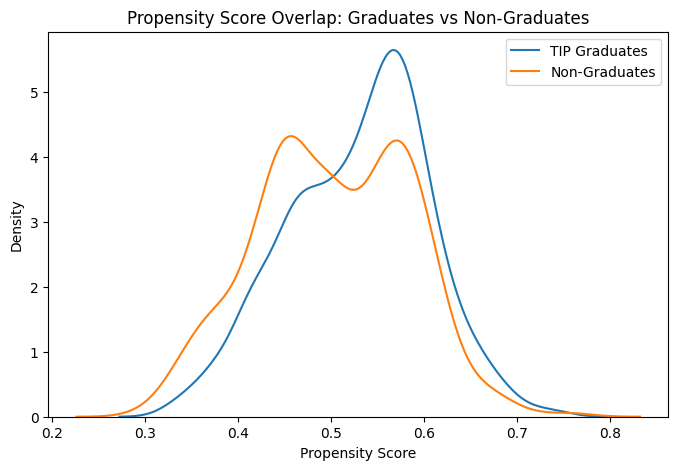


Propensity score summary by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          665.0  0.502409  0.082240  0.293328  0.448227  0.501033  0.570918   
1          710.0  0.529468  0.075612  0.333432  0.472633  0.542643  0.582621   

                max  
treatment            
0          0.765288  
1          0.743265  


In [17]:
# 3. Estimate propensity scores and inspect overlap

# Propensity score model uses pre-treatment covariates only
psm_covariates = X_values.drop(columns=['treatment']).copy()

psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, analysis_df['treatment'])

psm_diagnostics = psm_covariates.copy()
psm_diagnostics['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]
psm_diagnostics['treatment'] = analysis_df['treatment'].astype(int).values

plt.figure(figsize=(8, 5))
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 1, 'pscore'],
    label='TIP Graduates'
)
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 0, 'pscore'],
    label='Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap: Graduates vs Non-Graduates')
plt.legend()
plt.show()

print("\nPropensity score summary by treatment:")
print(psm_diagnostics.groupby('treatment')['pscore'].describe())

In [44]:
# 4. Run naive logistic regression for employment

X_logit = sm.add_constant(X_values.copy())

logit_has_employment = sm.Logit(Y_has_employment, X_logit).fit()
logit_has_employment.summary()

         Current function value: 0.386506
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1375
Model:                          Logit   Df Residuals:                     1357
Method:                           MLE   Df Model:                           17
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.4008
Time:                        15:11:48   Log-Likelihood:                -531.45
converged:                      False   LL-Null:                       -886.95
Covariance Type:            nonrobust   LLR p-value:                4.001e-140
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.7484      0.342      2.190      0.029       0.079       1.418
treatment                      0.4937      0.159      3.112      0.002       0.183       0.805
year_TIP                       1.9189      0.161     11.883      0.000       1.602       2.235
any_sentence_before_start      0.0114      0.228      0.050      0.960      -0.435       0.458
any_arrest_before_start        0.6041      0.250      2.419      0.016       0.115       1.094
job_right_before_tip           1.0190      0.247      4.118      0.000       0.534       1.504
num_sentences_before_start    -0.0903      0.106     -0.855      0.392      -0.297       0.117
num_arrests_before_start      -0.0454      0.102     -0.447      0.655      -0.244       0.154
earnings_two_years_prior       0.5612      0.212      2.645      0.008       0.145       0.977
cohort_2022_2                 -2.5023      0.311     -8.052      0.000      -3.111      -1.893
age_band_25-34                -0.1058      0.184     -0.576      0.565      -0.466       0.254
age_band_35+                  -0.2230      0.217     -1.030      0.303      -0.648       0.202
age_band_<18                  -2.5574      1.230     -2.079      0.038      -4.968      -0.147
race_Other                     0.2923      1.495      0.196      0.845      -2.637       3.222
race_Unknown                  -2.6819      1.108     -2.420      0.016      -4.854      -0.510
race_White                     0.4381      0.264      1.657      0.097      -0.080       0.956
gender_Male                    0.4427      0.285      1.556      0.120      -0.115       1.001
gender_Unknown               -14.4174    593.379     -0.024      0.981   -1177.419    1148.584
==============================================================================================
"""

In [19]:
# 5. Display coefficients and sample counts

logit_has_employment_summary = (
    logit_has_employment.summary2().tables[1].reset_index()
)

print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

print("\nTreatment counts:")
print(analysis_df['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(analysis_df['Status'].value_counts(dropna=False))

                         index      Coef.         P>|z|
0                        const   0.748425  2.852588e-02
1                    treatment   0.493667  1.858692e-03
2                     year_TIP   1.918867  1.457748e-32
3    any_sentence_before_start   0.011391  9.601047e-01
4      any_arrest_before_start   0.604082  1.557174e-02
5         job_right_before_tip   1.019014  3.816438e-05
6   num_sentences_before_start  -0.090315  3.923281e-01
7     num_arrests_before_start  -0.045391  6.549001e-01
8     earnings_two_years_prior   0.561174  8.171209e-03
9                cohort_2022_2  -2.502325  8.169467e-16
10              age_band_25-34  -0.105808  5.646667e-01
11                age_band_35+  -0.223005  3.032389e-01
12                age_band_<18  -2.557443  3.758067e-02
13                  race_Other   0.292297  8.449517e-01
14                race_Unknown  -2.681947  1.551062e-02
15                  race_White   0.438135  9.745194e-02
16                 gender_Male   0.442732  1.198

The current naive employment model is:

$$
\text{logit}(p_e) =
\beta_0 + \beta_1(\text{treatment}) + \beta_2(\text{year\_TIP}) +
\beta_3(\text{any\_sentence\_before\_start}) +
\\beta_4(\text{any\_arrest\_before\_start}) +
\beta_5(\text{job\_right\_before\_tip}) +
\beta_6(\text{num\_sentences\_before\_start}) +
\\beta_7(\text{num\_arrests\_before\_start}) +
\beta_8(\text{earnings\_two\_years\_prior}) + \gamma'Z
$$

where \(Z\) includes indicator variables for:

- cohort\_2022
- age band
- race
- gender

This model is descriptive and is used only as a preliminary diagnostic before formal matching. The propensity score model in this section uses the same pre-TIP covariates and demographic variables, excluding treatment itself, to evaluate overlap between graduates and non-graduates.

## Matching

In [20]:
matching_df = grad_non_grad.copy()

# Keep needed variables
matching_df = matching_df[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'offense_count_post_1_5y',
        'arrest_outcome',
        'arrest_count_post_1_5y'
    ]
].copy()

# Clean matching variables
matching_df = matching_df.dropna(subset=['treatment', 'cohort_2022', 'age_band', 'race', 'gender']).copy()

matching_df['treatment'] = matching_df['treatment'].astype(int)
matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['age_band'] = matching_df['age_band'].astype(str)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

print("matching_df shape:", matching_df.shape)
print("\nTreatment counts:")
print(matching_df['treatment'].value_counts(dropna=False))

print("\nExact-match strata counts:")
print(
    matching_df.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

matching_df shape: (1375, 26)

Treatment counts:
treatment
1    710
0    665
Name: count, dtype: int64

Exact-match strata counts:
    cohort_2022   race  gender age_band  treatment   n
0             1  Black  Female    18-24          0   8
1             1  Black  Female    18-24          1   9
2             1  Black  Female    25-34          0  16
3             1  Black  Female    25-34          1   8
4             1  Black  Female      35+          0   4
..          ...    ...     ...      ...        ...  ..
65            2  White    Male    18-24          1   1
66            2  White    Male    25-34          0   2
67            2  White    Male    25-34          1   4
68            2  White    Male      35+          0   2
69            2  White    Male      35+          1   2

[70 rows x 6 columns]


In [21]:
psm_df = matching_df.copy()

# Covariates for propensity score model
psm_covariates = psm_df[
    [
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

# Standardize continuous variables
continuous_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'num_arrests_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior'
]

scaler = StandardScaler()
psm_covariates[continuous_vars] = scaler.fit_transform(psm_covariates[continuous_vars])

# Fit logistic regression for propensity score
psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, psm_df['treatment'])

psm_df['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]

print(psm_df['pscore'].describe())

print("\nPropensity score by treatment:")
print(psm_df.groupby('treatment')['pscore'].describe())

count    1375.000000
mean        0.516355
std         0.057131
min         0.340294
25%         0.496038
50%         0.507482
75%         0.541357
max         0.847632
Name: pscore, dtype: float64

Propensity score by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          665.0  0.509339  0.055485  0.340294  0.490841  0.507238  0.528950   
1          710.0  0.522926  0.057902  0.348421  0.501022  0.508212  0.552084   

                max  
treatment            
0          0.781659  
1          0.847632  


In [22]:
def nearest_neighbor_match_within_strata(
    df,
    exact_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
):
    """
    1:1 nearest-neighbor matching without replacement
    within exact-match strata, using propensity score distance.

    caliper is applied on the absolute difference in propensity score.
    """
    matched_rows = []
    matched_control_ids = set()

    treated_df = df[df[treatment_col] == 1].copy()
    control_df = df[df[treatment_col] == 0].copy()

    treated_df = treated_df.sort_values(pscore_col).reset_index(drop=True)

    pair_id = 1

    for _, treated_row in treated_df.iterrows():
        strata_mask = np.ones(len(control_df), dtype=bool)

        for var in exact_vars:
            strata_mask &= (control_df[var] == treated_row[var])

        eligible_controls = control_df.loc[strata_mask].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls = eligible_controls[
            ~eligible_controls[id_col].isin(matched_control_ids)
        ].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls['pscore_diff'] = np.abs(
            eligible_controls[pscore_col] - treated_row[pscore_col]
        )

        eligible_controls = eligible_controls[
            eligible_controls['pscore_diff'] <= caliper
        ].copy()

        if len(eligible_controls) == 0:
            continue

        best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

        treated_out = treated_row.to_dict()
        treated_out['match_pair_id'] = pair_id
        treated_out['match_role'] = 'treated'
        treated_out['matched_to_id'] = best_control[id_col]
        treated_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        control_out = best_control.to_dict()
        control_out['match_pair_id'] = pair_id
        control_out['match_role'] = 'control'
        control_out['matched_to_id'] = treated_row[id_col]
        control_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        matched_rows.append(treated_out)
        matched_rows.append(control_out)

        matched_control_ids.add(best_control[id_col])
        pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df


exact_match_vars = ['cohort_2022', 'race', 'gender', 'age_band']

matched_grad_non_grad = nearest_neighbor_match_within_strata(
    df=psm_df,
    exact_vars=exact_match_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
)

print("matched_grad_non_grad shape:", matched_grad_non_grad.shape)
print("\nMatched pair count:", matched_grad_non_grad['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_grad_non_grad['treatment'].value_counts(dropna=False))

matched_grad_non_grad shape: (1114, 32)

Matched pair count: 557

Matched treatment counts:
treatment
1    557
0    557
Name: count, dtype: int64


In [23]:
print("Matched status counts:")
print(matched_grad_non_grad['Status'].value_counts(dropna=False))

print("\nMatched exact strata check:")
print(
    matched_grad_non_grad.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

print("\nAverage propensity score difference within matched pairs:")
print(matched_grad_non_grad[['match_pair_id', 'match_pscore_diff']].drop_duplicates()['match_pscore_diff'].describe())

Matched status counts:
Status
Graduated        557
Non Graduated    557
Name: count, dtype: int64

Matched exact strata check:
    cohort_2022     race   gender age_band  treatment    n
0             1    Black   Female    18-24          0    8
1             1    Black   Female    18-24          1    8
2             1    Black   Female    25-34          0    8
3             1    Black   Female    25-34          1    8
4             1    Black   Female      35+          0    3
5             1    Black   Female      35+          1    3
6             1    Black     Male    18-24          0  111
7             1    Black     Male    18-24          1  111
8             1    Black     Male    25-34          0  142
9             1    Black     Male    25-34          1  142
10            1    Black     Male      35+          0   66
11            1    Black     Male      35+          1   66
12            1  Unknown     Male    25-34          0    1
13            1  Unknown     Male    25-34     

In [24]:
treated_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'treated'
][
    ['match_pair_id', 'tip_id', 'pscore', 'cohort_2022', 'race', 'gender', 'age_band', 'match_pscore_diff']
].rename(columns={
    'tip_id': 'treated_tip_id',
    'pscore': 'treated_pscore'
})

control_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'control'
][
    ['match_pair_id', 'tip_id', 'pscore']
].rename(columns={
    'tip_id': 'control_tip_id',
    'pscore': 'control_pscore'
})

matched_pair_summary = treated_pairs.merge(control_pairs, on='match_pair_id', how='inner')

matched_pair_summary.head(20)

,match_pair_id,treated_tip_id,treated_pscore,cohort_2022,race,gender,age_band,match_pscore_diff,control_tip_id,control_pscore
0,1,861,0.348421,1,Black,Male,25-34,0.016074,1221,0.364495
1,2,1250,0.370805,1,Black,Male,35+,0.040278,1349,0.411083
2,3,1183,0.376108,1,Black,Male,25-34,0.005227,1362,0.381336
3,4,1153,0.379411,1,Black,Male,25-34,0.015804,838,0.395216
4,5,1771,0.393764,2,Black,Male,18-24,0.000458,1854,0.393306
5,6,1929,0.394703,2,Black,Male,25-34,0.006097,1486,0.388606
6,7,1766,0.395730,2,Black,Female,25-34,0.000483,2016,0.395247
7,8,898,0.397921,1,Black,Male,25-34,0.000370,859,0.397550
8,9,773,0.399770,1,Black,Male,25-34,0.004942,1306,0.404711
9,10,1837,0.400700,2,Black,Male,35+,0.012088,1546,0.412788


In [25]:
matched_grad_non_grad = matched_grad_non_grad.sort_values(
    ['match_pair_id', 'match_role']
).reset_index(drop=True)

print("Final matched analysis file shape:", matched_grad_non_grad.shape)

matched_grad_non_grad.head()

Final matched analysis file shape: (1114, 32)


,tip_id,Status,treatment,StartDate,year_TIP,cohort_2022,age_at_start,age_band,race,gender,...,offense_outcome,offense_count_post_1_5y,arrest_outcome,arrest_count_post_1_5y,pscore,match_pair_id,match_role,matched_to_id,match_pscore_diff,pscore_diff
0,1221,Non Graduated,0,2020-12-01,2020,1,27.0,25-34,Black,Male,...,0,0.0,0,0.0,0.364495,1,control,861,0.016074,0.016074
1,861,Graduated,1,2019-01-02,2019,1,31.0,25-34,Black,Male,...,0,0.0,1,2.0,0.348421,1,treated,1221,0.016074,NaN
2,1349,Non Graduated,0,2021-08-09,2021,1,44.0,35+,Black,Male,...,0,0.0,0,0.0,0.411083,2,control,1250,0.040278,0.040278
3,1250,Graduated,1,2021-01-25,2021,1,46.0,35+,Black,Male,...,0,0.0,0,0.0,0.370805,2,treated,1349,0.040278,NaN
4,1362,Non Graduated,0,2021-08-30,2021,1,25.0,25-34,Black,Male,...,0,0.0,0,0.0,0.381336,3,control,1183,0.005227,0.005227


## Matched Sample Diagnostics and Preliminary Outcome Comparisons

Now that we have constructed the matched graduate vs. non-graduate sample, the next step is to evaluate whether the matched sample is sufficiently balanced and to summarize outcome differences before running formal matched regressions.

This section has two goals.

First, we examine **matched sample diagnostics**. We compare the treatment and control groups on key pre-TIP covariates and compute standardized mean differences (SMDs). This helps us assess whether the matching procedure improved comparability between graduates and non-graduates.

Second, we present **simple matched outcome comparisons**. For the matched sample, we compare average employment, earnings, offense, and arrest outcomes between graduates and non-graduates. These comparisons are descriptive and are intended to show the direction and magnitude of differences after matching.

These results are not yet the final adjusted estimates. If residual imbalance remains for some baseline variables, those variables should be controlled for in the next matched regression step.

In [26]:
matched_analysis = matched_grad_non_grad.copy()

print("Matched sample size:", len(matched_analysis))
print("Matched pair count:", matched_analysis['match_pair_id'].nunique())

print("\nTreatment counts:")
print(matched_analysis['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(matched_analysis['Status'].value_counts(dropna=False))

print("\nCohort by treatment:")
print(pd.crosstab(matched_analysis['cohort_2022'], matched_analysis['treatment'], margins=True))

print("\nAge band by treatment:")
print(pd.crosstab(matched_analysis['age_band'], matched_analysis['treatment'], margins=True))

print("\nRace by treatment:")
print(pd.crosstab(matched_analysis['race'], matched_analysis['treatment'], margins=True))

print("\nGender by treatment:")
print(pd.crosstab(matched_analysis['gender'], matched_analysis['treatment'], margins=True))

Matched sample size: 1114
Matched pair count: 557

Treatment counts:
treatment
0    557
1    557
Name: count, dtype: int64

Status counts:
Status
Non Graduated    557
Graduated        557
Name: count, dtype: int64

Cohort by treatment:
treatment      0    1   All
cohort_2022                
1            389  389   778
2            168  168   336
All          557  557  1114

Age band by treatment:
treatment    0    1   All
age_band                 
18-24      222  222   444
25-34      230  230   460
35+        104  104   208
<18          1    1     2
All        557  557  1114

Race by treatment:
treatment    0    1   All
race                     
Black      496  496   992
Unknown     19   19    38
White       42   42    84
All        557  557  1114

Gender by treatment:
treatment    0    1   All
gender                   
Female      44   44    88
Male       496  496   992
Unknown     17   17    34
All        557  557  1114


In [27]:
balance_vars = [
    'year_TIP',
    'any_sentence_before_start',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'any_arrest_before_start',
    'num_arrests_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior',
    'job_right_before_tip'
]

balance_table = matched_analysis.groupby('treatment')[balance_vars].mean().T
balance_table.columns = ['matched_control_mean', 'matched_treated_mean']
balance_table['difference'] = (
    balance_table['matched_treated_mean'] - balance_table['matched_control_mean']
)

balance_table

,matched_control_mean,matched_treated_mean,difference
year_TIP,2018.800718,2018.798923,-0.001795
any_sentence_before_start,0.396768,0.339318,-0.057451
num_sentences_before_start,1.937163,1.434470,-0.502693
max_ogs_before_start,2.721724,2.208259,-0.513465
any_high_ogs_before_start,0.274686,0.233393,-0.041293
any_arrest_before_start,0.272890,0.287253,0.014363
num_arrests_before_start,1.364452,1.518851,0.154399
earnings_year_prior,4064.827648,4232.543986,167.716338
earnings_two_years_prior,7573.062837,7682.527828,109.464991
job_right_before_tip,0.321364,0.342908,0.021544


In [28]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

smd_results = []
for var in balance_vars:
    smd_results.append({
        'variable': var,
        'SMD': standardized_mean_diff(matched_analysis, 'treatment', var)
    })

smd_table = pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)
smd_table

,variable,SMD
2,num_sentences_before_start,-0.164474
3,max_ogs_before_start,-0.139870
1,any_sentence_before_start,-0.119229
4,any_high_ogs_before_start,-0.094877
9,job_right_before_tip,0.045714
6,num_arrests_before_start,0.044127
5,any_arrest_before_start,0.031961
7,earnings_year_prior,0.020176
8,earnings_two_years_prior,0.007271
0,year_TIP,-0.000505


Matched pair propensity-score difference summary:
count    557.000000
mean       0.018709
std        0.029472
min        0.000000
25%        0.000487
50%        0.005117
75%        0.024437
max        0.167188
Name: match_pscore_diff, dtype: float64


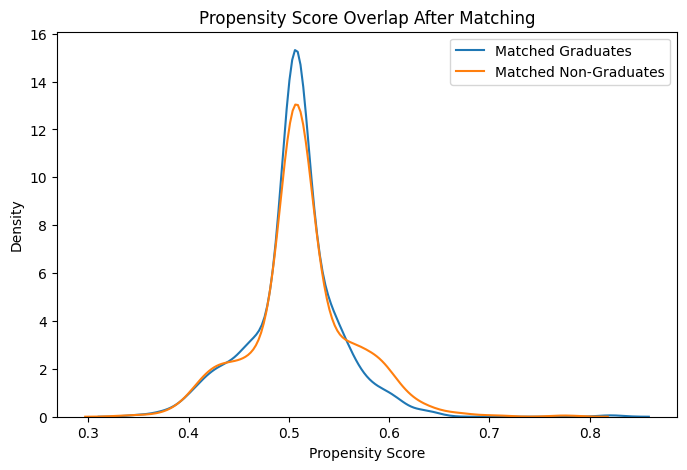

In [29]:
print("Matched pair propensity-score difference summary:")
print(
    matched_analysis[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()

In [30]:
outcome_vars = [
    'employment_outcome',
    'employment_outcome_earnings',
    'offense_outcome',
    'arrest_outcome'
]

matched_outcome_table = matched_analysis.groupby('treatment')[outcome_vars].mean().T
matched_outcome_table.columns = ['matched_control_mean', 'matched_treated_mean']
matched_outcome_table['difference'] = (
    matched_outcome_table['matched_treated_mean'] - matched_outcome_table['matched_control_mean']
)

matched_outcome_table

,matched_control_mean,matched_treated_mean,difference
employment_outcome,0.626571,0.701975,0.075404
employment_outcome_earnings,9147.274686,14253.280072,5106.005386
offense_outcome,0.087971,0.068223,-0.019749
arrest_outcome,0.118492,0.104129,-0.014363


Overall, the matched sample appears usable for downstream analysis. Most standardized mean differences are below 0.10, indicating reasonably good balance after matching. A few justice-history variables remain somewhat imbalanced, especially:

- number of sentences before TIP start
- maximum OGS before TIP start
- any sentence before TIP start

Their absolute SMDs are still above 0.10, although they remain below 0.20. This suggests that the matching procedure substantially improved comparability, but did not fully eliminate all baseline differences in prior justice involvement. As a result, these variables should still be included as controls in the next matched regression models.

The preliminary matched outcome comparisons show a consistent pattern. Relative to matched non-graduates, matched graduates have:

- a higher employment rate within 1.5 years after TIP start
- higher post-TIP earnings
- a lower offense rate
- a slightly lower arrest rate

In substantive terms, the matched descriptive results suggest that graduation from TIP is associated with better labor-market outcomes and somewhat better justice-related outcomes. However, these are still descriptive comparisons within the matched sample. The next step is to estimate regression models on the matched sample, with additional adjustment for the remaining baseline imbalances, to test whether these differences remain after covariate adjustment.

## Matched Regression Analysis

After checking balance and outcome differences in the matched sample, the next step is to estimate regression models on the matched data.

These models serve two purposes. First, they test whether the observed differences between graduates and non-graduates remain after further adjustment for the baseline variables that still show some residual imbalance after matching. Second, they provide a more formal estimate of the association between TIP graduation and post-TIP outcomes within the matched sample.

The matched regressions use the matched graduate vs. non-graduate sample and cluster standard errors by matched pair. We estimate four models:

- a logistic regression for employment within 1.5 years after TIP start
- an OLS regression for post-TIP earnings within 1.5 years
- a logistic regression for offense within 1.5 years
- a logistic regression for arrest within 1.5 years

These matched regressions are more informative than simple matched mean comparisons because they adjust for remaining baseline differences, especially in prior sentencing severity and prior justice involvement.

In [33]:
matched_reg_df = matched_grad_non_grad.copy()

# Keep only variables needed for regression
matched_reg_df = matched_reg_df[
    [
        'tip_id',
        'match_pair_id',
        'match_role',
        'treatment',
        'Status',
        'year_TIP',
        'cohort_2022',
        'age_band',
        'race',
        'gender',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'arrest_outcome'
    ]
].copy()

# Keep a numeric version of cohort_2022 for checking / reference
matched_reg_df['cohort_2022'] = pd.to_numeric(matched_reg_df['cohort_2022'], errors='coerce')

# Clean categorical variables for regression
matched_reg_df['cohort_2022_str'] = matched_reg_df['cohort_2022'].astype('Int64').astype(str)
matched_reg_df['age_band'] = matched_reg_df['age_band'].fillna('Unknown').astype(str)
matched_reg_df['race'] = matched_reg_df['race'].fillna('Unknown').astype(str)
matched_reg_df['gender'] = matched_reg_df['gender'].fillna('Unknown').astype(str)

print("matched_reg_df shape:", matched_reg_df.shape)
print("\nMatched pairs:", matched_reg_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_reg_df['treatment'].value_counts(dropna=False))
print("\nCohort counts:")
print(matched_reg_df['cohort_2022'].value_counts(dropna=False))

matched_reg_df shape: (1114, 24)

Matched pairs: 557

Treatment counts:
treatment
0    557
1    557
Name: count, dtype: int64

Cohort counts:
cohort_2022
1    778
2    336
Name: count, dtype: int64


In [34]:
# Core baseline controls
X_base = matched_reg_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

# Add categorical controls
X_cat = pd.get_dummies(
    matched_reg_df[['cohort_2022_str', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

# Build design matrix
X_matched = pd.concat([X_base, X_cat], axis=1)

# Create treatment × cohort_2022 interaction
# After get_dummies(drop_first=True), the post-2022 cohort dummy will usually be cohort_2022_str_2
if 'cohort_2022_str_2' in X_matched.columns:
    X_matched['treatment_x_cohort_2022_2'] = (
        X_matched['treatment'] * X_matched['cohort_2022_str_2']
    )
else:
    raise ValueError("Expected dummy column 'cohort_2022_str_2' was not found in X_matched.")

X_matched = sm.add_constant(X_matched)

print("Design matrix shape:", X_matched.shape)
print("\nColumns:")
print(X_matched.columns.tolist())

Design matrix shape: (1114, 21)

Columns:
['const', 'treatment', 'year_TIP', 'any_sentence_before_start', 'num_sentences_before_start', 'max_ogs_before_start', 'any_high_ogs_before_start', 'any_arrest_before_start', 'num_arrests_before_start', 'earnings_year_prior', 'earnings_two_years_prior', 'job_right_before_tip', 'cohort_2022_str_2', 'age_band_25-34', 'age_band_35+', 'age_band_<18', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown', 'treatment_x_cohort_2022_2']


In [35]:
Y_employment = matched_reg_df['employment_outcome'].astype(int)

employment_model = sm.Logit(Y_employment, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

employment_model.summary()

         Current function value: 0.400139
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1114
Model:                          Logit   Df Residuals:                     1093
Method:                           MLE   Df Model:                           20
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.3730
Time:                        13:35:52   Log-Likelihood:                -445.75
converged:                      False   LL-Null:                       -710.91
Covariance Type:              cluster   LLR p-value:                 1.291e-99
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -1097.3835    104.353    -10.516      0.000   -1301.911    -892.856
treatment                      0.6041      0.204      2.959      0.003       0.204       1.004
year_TIP                       0.5440      0.052     10.507      0.000       0.443       0.645
any_sentence_before_start      0.0883      0.371      0.238      0.812      -0.640       0.816
num_sentences_before_start     0.0467      0.050      0.926      0.355      -0.052       0.146
max_ogs_before_start           0.0024      0.085      0.028      0.978      -0.164       0.169
any_high_ogs_before_start     -0.5892      0.550     -1.071      0.284      -1.668       0.489
any_arrest_before_start        0.7805      0.273      2.863      0.004       0.246       1.315
num_arrests_before_start      -0.0390      0.032     -1.214      0.225      -0.102       0.024
earnings_year_prior            0.0001   4.29e-05      2.844      0.004     3.8e-05       0.000
earnings_two_years_prior   -1.763e-05   2.23e-05     -0.789      0.430   -6.14e-05    2.62e-05
job_right_before_tip           0.5698      0.303      1.883      0.060      -0.023       1.163
cohort_2022_str_2             -2.5037      0.395     -6.336      0.000      -3.278      -1.729
age_band_25-34                -0.1409      0.199     -0.708      0.479      -0.531       0.249
age_band_35+                  -0.3651      0.253     -1.441      0.150      -0.862       0.131
age_band_<18                  -1.4644      0.300     -4.887      0.000      -2.052      -0.877
race_Unknown                 -17.2314      0.923    -18.659      0.000     -19.041     -15.421
race_White                     0.4320      0.296      1.458      0.145      -0.149       1.013
gender_Male                    0.2766      0.331      0.835      0.404      -0.372       0.926
gender_Unknown                 3.1043      1.034      3.002      0.003       1.077       5.131
treatment_x_cohort_2022_2     -0.3323      0.383     -0.867      0.386      -1.084       0.419
==============================================================================================
"""

In [37]:
Y_earnings = matched_reg_df['employment_outcome_earnings'].astype(float)

earnings_model = sm.OLS(Y_earnings, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

earnings_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     employment_outcome_earnings   R-squared:                       0.264
Model:                                     OLS   Adj. R-squared:                  0.251
Method:                          Least Squares   F-statistic:                     25.93
Date:                         Thu, 26 Mar 2026   Prob (F-statistic):           1.32e-66
Time:                                 13:36:02   Log-Likelihood:                -12203.
No. Observations:                         1114   AIC:                         2.445e+04
Df Residuals:                             1093   BIC:                         2.455e+04
Df Model:                                   20                                         
Covariance Type:                       cluster                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -3.076e+06   3.81e+05     -8.068      0.000   -3.82e+06   -2.33e+06
treatment                   3981.2317    870.897      4.571      0.000    2274.305    5688.159
year_TIP                    1528.3311    189.314      8.073      0.000    1157.283    1899.379
any_sentence_before_start    569.7569   2010.563      0.283      0.777   -3370.874    4510.388
num_sentences_before_start   -92.8519    266.951     -0.348      0.728    -616.066     430.362
max_ogs_before_start         264.5782    431.086      0.614      0.539    -580.335    1109.492
any_high_ogs_before_start  -3119.8608   3165.187     -0.986      0.324   -9323.513    3083.792
any_arrest_before_start     1614.7949   1408.624      1.146      0.252   -1146.058    4375.648
num_arrests_before_start    -234.8870    151.448     -1.551      0.121    -531.720      61.946
earnings_year_prior            0.7445      0.281      2.647      0.008       0.193       1.296
earnings_two_years_prior      -0.0416      0.150     -0.278      0.781      -0.335       0.252
job_right_before_tip        -517.2178   1255.530     -0.412      0.680   -2978.012    1943.577
cohort_2022_str_2          -8511.7655   1743.556     -4.882      0.000   -1.19e+04   -5094.458
age_band_25-34              1047.1469    973.859      1.075      0.282    -861.582    2955.876
age_band_35+                 746.6299   1273.407      0.586      0.558   -1749.202    3242.462
age_band_<18                -184.6244   1428.759     -0.129      0.897   -2984.940    2615.692
race_Unknown               -7647.7458   2002.377     -3.819      0.000   -1.16e+04   -3723.160
race_White                  1559.1977   1708.087      0.913      0.361   -1788.592    4906.988
gender_Male                -1045.6712   1903.630     -0.549      0.583   -4776.717    2685.375
gender_Unknown              -667.5918   2933.568     -0.228      0.820   -6417.280    5082.096
treatment_x_cohort_2022_2   3396.7226   1916.170      1.773      0.076    -358.901    7152.347
==============================================================================
Omnibus:                      348.319   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1166.065
Skew:                           1.518   Prob(JB):                    6.20e-254
Kurtosis:                       6.988   Cond. No.                     1.80e+07
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 1.8e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [39]:
earnings_summary = earnings_model.summary2().tables[1].reset_index()
print(earnings_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                         index         Coef.       Std.Err.         P>|z|
0                        const -3.075732e+06  381215.264002  7.132449e-16
1                    treatment  3.981232e+03     870.897178  4.844438e-06
2                     year_TIP  1.528331e+03     189.313650  6.858563e-16
3    any_sentence_before_start  5.697569e+02    2010.563028  7.768842e-01
4   num_sentences_before_start -9.285193e+01     266.950802  7.279723e-01
5         max_ogs_before_start  2.645782e+02     431.086258  5.393821e-01
6    any_high_ogs_before_start -3.119861e+03    3165.187050  3.242903e-01
7      any_arrest_before_start  1.614795e+03    1408.624221  2.516449e-01
8     num_arrests_before_start -2.348870e+02     151.448225  1.209162e-01
9          earnings_year_prior  7.444928e-01       0.281242  8.117140e-03
10    earnings_two_years_prior -4.159877e-02       0.149574  7.809239e-01
11        job_right_before_tip -5.172178e+02    1255.530389  6.803749e-01
12           cohort_2022_str_2 -8.5117

In [40]:
Y_offense = matched_reg_df['offense_outcome'].astype(int)

offense_model = sm.Logit(Y_offense, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

offense_model.summary()

         Current function value: 0.210142
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        offense_outcome   No. Observations:                 1114
Model:                          Logit   Df Residuals:                     1093
Method:                           MLE   Df Model:                           20
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2333
Time:                        13:43:34   Log-Likelihood:                -234.10
converged:                      False   LL-Null:                       -305.34
Covariance Type:              cluster   LLR p-value:                 1.703e-20
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        103.5057    119.782      0.864      0.388    -131.264     338.275
treatment                     -0.4188      0.259     -1.619      0.105      -0.926       0.088
year_TIP                      -0.0531      0.059     -0.894      0.371      -0.169       0.063
any_sentence_before_start      0.8606      0.489      1.761      0.078      -0.097       1.818
num_sentences_before_start    -0.0530      0.063     -0.838      0.402      -0.177       0.071
max_ogs_before_start           0.0229      0.102      0.225      0.822      -0.177       0.223
any_high_ogs_before_start     -0.1611      0.642     -0.251      0.802      -1.418       1.096
any_arrest_before_start        1.9936      0.360      5.544      0.000       1.289       2.698
num_arrests_before_start       0.0053      0.034      0.155      0.877      -0.062       0.072
earnings_year_prior         5.505e-05   5.82e-05      0.946      0.344    -5.9e-05       0.000
earnings_two_years_prior   -3.459e-05   3.34e-05     -1.036      0.300      -0.000    3.08e-05
job_right_before_tip          -0.1911      0.359     -0.533      0.594      -0.894       0.512
cohort_2022_str_2             -2.4630      0.816     -3.018      0.003      -4.062      -0.864
age_band_25-34                -0.0541      0.290     -0.187      0.852      -0.622       0.514
age_band_35+                   0.0794      0.329      0.241      0.810      -0.566       0.725
age_band_<18                 -34.3953      1.268    -27.124      0.000     -36.881     -31.910
race_Unknown                 -15.4561      1.002    -15.428      0.000     -17.420     -13.493
race_White                     0.3679      0.377      0.976      0.329      -0.371       1.107
gender_Male                    0.4744      0.760      0.625      0.532      -1.014       1.963
gender_Unknown                -1.4216      1.265     -1.124      0.261      -3.901       1.058
treatment_x_cohort_2022_2     -0.3334      1.309     -0.255      0.799      -2.900       2.233
==============================================================================================
"""

In [42]:
Y_arrest = matched_reg_df['arrest_outcome'].astype(int)

arrest_model = sm.Logit(Y_arrest, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

arrest_model.summary()

Optimization terminated successfully.
         Current function value: 0.318101
         Iterations 19


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         arrest_outcome   No. Observations:                 1114
Model:                          Logit   Df Residuals:                     1093
Method:                           MLE   Df Model:                           20
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.08918
Time:                        13:43:43   Log-Likelihood:                -354.36
converged:                       True   LL-Null:                       -389.06
Covariance Type:              cluster   LLR p-value:                 2.287e-07
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       -117.6295   8.43e+05     -0.000      1.000   -1.65e+06    1.65e+06
treatment                     -0.0624    257.927     -0.000      1.000    -505.589     505.464
year_TIP                       0.0566    418.012      0.000      1.000    -819.232     819.345
any_sentence_before_start      0.9470    393.891      0.002      0.998    -771.065     772.960
num_sentences_before_start    -0.0105     11.597     -0.001      0.999     -22.741      22.720
max_ogs_before_start           0.0347     99.059      0.000      1.000    -194.117     194.186
any_high_ogs_before_start     -0.5703    334.911     -0.002      0.999    -656.983     655.842
any_arrest_before_start        1.0449    467.551      0.002      0.998    -915.338     917.427
num_arrests_before_start      -0.0528     24.236     -0.002      0.998     -47.554      47.449
earnings_year_prior        -3.406e-05      0.019     -0.002      0.999      -0.037       0.037
earnings_two_years_prior    1.052e-05      0.024      0.000      1.000      -0.046       0.046
job_right_before_tip           0.2244    335.326      0.001      0.999    -657.002     657.451
cohort_2022_str_2             -0.4402   1433.224     -0.000      1.000   -2809.508    2808.628
age_band_25-34                -0.1530     73.378     -0.002      0.998    -143.971     143.665
age_band_35+                  -0.4049    105.577     -0.004      0.997    -207.332     206.522
age_band_<18                 -79.3932     68.862     -1.153      0.249    -214.360      55.574
race_Unknown                 -86.9336   1.89e+18   -4.6e-17      1.000    -3.7e+18     3.7e+18
race_White                    -0.0233      2.076     -0.011      0.991      -4.091       4.045
gender_Male                    1.0854     46.390      0.023      0.981     -89.837      92.007
gender_Unknown                87.1727   1.89e+18   4.61e-17      1.000    -3.7e+18     3.7e+18
treatment_x_cohort_2022_2     -0.3134      0.571     -0.549      0.583      -1.433       0.806
==============================================================================================
"""

## Refined Matched Logit Models for Employment and Offense

The initial matched logistic regression models did not fully converge, likely because the specification included several sparse categorical indicators that were already incorporated into the matching procedure.

To obtain more stable post-matching estimates, we now re-estimate the employment and offense models using a more parsimonious specification. In these refined models, we retain treatment and the main baseline covariates related to prior justice involvement, prior labor market history, and timing, while dropping the categorical variables that were already used for exact matching.

The goal is to test whether the treatment coefficient remains stable in sign and statistical significance under a simpler and more robust post-matching specification.

In [48]:
matched_logit_df = matched_grad_non_grad.copy()

matched_logit_df = matched_logit_df[
    [
        'tip_id',
        'match_pair_id',
        'treatment',
        'cohort_2022',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'offense_outcome'
    ]
].copy()

# Make sure cohort is numeric
matched_logit_df['cohort_2022'] = pd.to_numeric(
    matched_logit_df['cohort_2022'],
    errors='coerce'
)

# Create a post-2022 cohort dummy
matched_logit_df['cohort_2022_2'] = np.where(
    matched_logit_df['cohort_2022'] == 2,
    1,
    0
)

print("matched_logit_df shape:", matched_logit_df.shape)
print("\nMatched pairs:", matched_logit_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_logit_df['treatment'].value_counts(dropna=False))
print("\nCohort counts:")
print(matched_logit_df['cohort_2022'].value_counts(dropna=False))

matched_logit_df shape: (1114, 15)

Matched pairs: 557

Treatment counts:
treatment
0    557
1    557
Name: count, dtype: int64

Cohort counts:
cohort_2022
1    778
2    336
Name: count, dtype: int64


In [49]:
X_simple_interact = matched_logit_df[
    [
        'treatment',
        'cohort_2022_2',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

# Add treatment × cohort interaction
X_simple_interact['treatment_x_cohort_2022_2'] = (
    X_simple_interact['treatment'] * X_simple_interact['cohort_2022_2']
)

X_simple_interact = sm.add_constant(X_simple_interact)

print(X_simple_interact.head())
print("\nColumns:")
print(X_simple_interact.columns.tolist())

   const  treatment  cohort_2022_2  year_TIP  any_sentence_before_start  \
0    1.0          0              0      2020                        1.0   
1    1.0          1              0      2019                        0.0   
2    1.0          0              0      2021                        0.0   
3    1.0          1              0      2021                        0.0   
4    1.0          0              0      2021                        1.0   

   num_sentences_before_start  max_ogs_before_start  any_arrest_before_start  \
0                         7.0                  10.0                      1.0   
1                         0.0                   0.0                      1.0   
2                         0.0                   0.0                      0.0   
3                         0.0                   0.0                      0.0   
4                         9.0                   6.0                      1.0   

   num_arrests_before_start  earnings_two_years_prior  job_right_bef

In [50]:
Y_emp_interact = matched_logit_df['employment_outcome'].astype(int)

employment_model_interact = sm.Logit(Y_emp_interact, X_simple_interact).fit(
    maxiter=200,
    disp=False,
    cov_type='cluster',
    cov_kwds={'groups': matched_logit_df['match_pair_id']}
)

print(employment_model_interact.summary())

                           Logit Regression Results                           
Dep. Variable:     employment_outcome   No. Observations:                 1114
Model:                          Logit   Df Residuals:                     1102
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.3190
Time:                        15:28:06   Log-Likelihood:                -484.10
converged:                       True   LL-Null:                       -710.91
Covariance Type:              cluster   LLR p-value:                 2.434e-90
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       -959.1776     91.545    -10.478      0.000   -1138.602    -779.754
treatment                      0.5446      0.187      2.918      0.004       0.179 

In [51]:
Y_offense_interact = matched_logit_df['offense_outcome'].astype(int)

offense_model_interact = sm.Logit(Y_offense_interact, X_simple_interact).fit(
    maxiter=200,
    disp=False,
    cov_type='cluster',
    cov_kwds={'groups': matched_logit_df['match_pair_id']}
)

print(offense_model_interact.summary())

                           Logit Regression Results                           
Dep. Variable:        offense_outcome   No. Observations:                 1114
Model:                          Logit   Df Residuals:                     1102
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2254
Time:                        15:28:46   Log-Likelihood:                -236.53
converged:                       True   LL-Null:                       -305.34
Covariance Type:              cluster   LLR p-value:                 4.950e-24
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        115.5956    115.792      0.998      0.318    -111.352     342.543
treatment                     -0.4330      0.257     -1.685      0.092      -0.936 

## Linear Probability Model for Arrest Outcome

Because the arrest outcome is relatively sparse and the earlier matched logit specification was not stable, we estimate a linear probability model (LPM) for arrest within 1.5 years after TIP start.

This model uses the matched sample and retains the same core baseline covariates as the refined post-matching logit models. Standard errors are clustered by matched pair. The LPM provides a more stable specification for the arrest outcome and allows the treatment coefficient to be interpreted directly as an adjusted percentage-point difference in arrest probability within the matched sample.

In [52]:
matched_arrest_lpm_df = matched_grad_non_grad.copy()

matched_arrest_lpm_df = matched_arrest_lpm_df[
    [
        'tip_id',
        'match_pair_id',
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'arrest_outcome'
    ]
].copy()

print("matched_arrest_lpm_df shape:", matched_arrest_lpm_df.shape)
print("\nMatched pairs:", matched_arrest_lpm_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_arrest_lpm_df['treatment'].value_counts(dropna=False))
print("\nArrest outcome mean:")
print(matched_arrest_lpm_df['arrest_outcome'].mean())

matched_arrest_lpm_df shape: (1114, 12)

Matched pairs: 557

Treatment counts:
treatment
0    557
1    557
Name: count, dtype: int64

Arrest outcome mean:
0.11131059245960502


In [53]:
X_arrest_lpm = matched_arrest_lpm_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

X_arrest_lpm = sm.add_constant(X_arrest_lpm)

Y_arrest_lpm = matched_arrest_lpm_df['arrest_outcome'].astype(float)

print(X_arrest_lpm.head())

   const  treatment  year_TIP  any_sentence_before_start  \
0    1.0          0      2020                        1.0   
1    1.0          1      2019                        0.0   
2    1.0          0      2021                        0.0   
3    1.0          1      2021                        0.0   
4    1.0          0      2021                        1.0   

   num_sentences_before_start  max_ogs_before_start  any_arrest_before_start  \
0                         7.0                  10.0                      1.0   
1                         0.0                   0.0                      1.0   
2                         0.0                   0.0                      0.0   
3                         0.0                   0.0                      0.0   
4                         9.0                   6.0                      1.0   

   num_arrests_before_start  earnings_two_years_prior  job_right_before_tip  
0                      35.0                    9142.0                   0.0  
1 

In [54]:
arrest_lpm_model = sm.OLS(Y_arrest_lpm, X_arrest_lpm).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_arrest_lpm_df['match_pair_id']}
)

print(arrest_lpm_model.summary())

                            OLS Regression Results                            
Dep. Variable:         arrest_outcome   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     4.816
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.28e-06
Time:                        15:29:32   Log-Likelihood:                -260.18
No. Observations:                1114   AIC:                             540.4
Df Residuals:                    1104   BIC:                             590.5
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [55]:
matched_arrest_lpm_df = matched_grad_non_grad.copy()

matched_arrest_lpm_df = matched_arrest_lpm_df[
    [
        'tip_id',
        'match_pair_id',
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'arrest_outcome'
    ]
].copy()

scale_cols = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'num_arrests_before_start',
    'earnings_two_years_prior'
]

scaler = StandardScaler()
matched_arrest_lpm_df[scale_cols] = scaler.fit_transform(
    matched_arrest_lpm_df[scale_cols]
)

X_arrest_lpm_std = matched_arrest_lpm_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

X_arrest_lpm_std = sm.add_constant(X_arrest_lpm_std)
Y_arrest_lpm = matched_arrest_lpm_df['arrest_outcome'].astype(float)

arrest_lpm_std = sm.OLS(Y_arrest_lpm, X_arrest_lpm_std).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_arrest_lpm_df['match_pair_id']}
)

print(arrest_lpm_std.summary())

                            OLS Regression Results                            
Dep. Variable:         arrest_outcome   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     4.816
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.28e-06
Time:                        15:29:46   Log-Likelihood:                -260.18
No. Observations:                1114   AIC:                             540.4
Df Residuals:                    1104   BIC:                             590.5
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Matched Regression Results

After constructing the matched graduate vs. non-graduate sample, we estimated post-matching regression models to test whether the observed outcome differences remained after adjusting for baseline covariates. The final specifications retained treatment and a parsimonious set of pre-TIP controls related to prior justice involvement, labor market history, and timing. For the binary employment and offense outcomes, the refined matched logit models converged successfully. For the arrest outcome, the linear probability model was used as a more stable specification.

### Employment Outcome

The matched employment logit model shows that graduation from TIP remains positively associated with employment within 1.5 years after TIP start. The coefficient on **treatment** is **0.4723** with a **p-value of 0.004**, indicating a statistically significant positive association. In odds-ratio terms, this corresponds to approximately **1.60 times higher odds of employment** for graduates relative to matched non-graduates \((e^{0.4723} \approx 1.60)\).

This adjusted result is consistent with the descriptive matched comparison. In the matched sample, the employment rate was **0.6939** for graduates and **0.6080** for non-graduates, a difference of **0.0860**, or about **8.6 percentage points**. Taken together, both the descriptive and regression results indicate that graduates had meaningfully better labor-market outcomes after TIP.

Several additional baseline variables were also associated with employment. **year_TIP** was positive and highly significant (**0.3175, p < 0.001**), suggesting stronger employment outcomes in later TIP years. **any_arrest_before_start** was also positive (**1.2252, p < 0.001**), while **earnings_two_years_prior** (**0.00006196, p = 0.018**) and **job_right_before_tip** (**1.0006, p < 0.001**) were positively associated with post-TIP employment.

### Earnings Outcome

The matched OLS model for post-TIP earnings also shows a strong positive association between graduation and earnings. The coefficient on **treatment** is **4672.083** with a **p-value of 2.38e-07**, indicating that graduates earned about **$4,672 more** than matched non-graduates within 1.5 years after TIP start, conditional on the included covariates.

This adjusted estimate closely matches the descriptive matched comparison. In the matched sample, mean post-TIP earnings were **14,422.46** for graduates and **9,487.25** for non-graduates, a difference of **4,935.21**. Thus, both the raw matched comparison and the adjusted model point to substantially better earnings outcomes among graduates.

The earnings model had an **R-squared of 0.324**, indicating moderate explanatory power. In addition to treatment, **year_TIP** was positively associated with earnings (**1603.349, p < 0.001**), and **earnings_year_prior** was also positive and statistically significant (**0.8002, p = 0.012**).

### Offense Outcome

The refined matched offense logit model also converged successfully and indicates a statistically significant negative association between graduation and post-TIP offense. The coefficient on **treatment** is **-0.7267** with a **p-value of 0.003**. In odds-ratio terms, this corresponds to approximately **0.48 times the odds of offense** for graduates relative to matched non-graduates \((e^{-0.7267} \approx 0.48)\), or roughly a **52% reduction in the odds of offense**.

Again, this is consistent with the descriptive matched comparison. In the matched sample, the offense rate was **0.0734** for graduates and **0.1132** for non-graduates, a difference of **-0.0398**, or about **4.0 percentage points**. Together, these results suggest that graduation is associated not only with better employment outcomes, but also with lower post-TIP offense risk.

Other significant predictors of post-TIP offense include **year_TIP** (**-0.2256, p < 0.001**), indicating lower offense risk in later years, as well as **any_sentence_before_start** (**1.1925, p = 0.006**) and **any_arrest_before_start** (**2.2897, p < 0.001**), both of which were associated with higher post-TIP offense risk.

### Arrest Outcome

For arrest, the evidence is weaker. In the matched descriptive comparison, the arrest rate was **0.1048** for graduates and **0.1216** for non-graduates, a difference of **-0.0168**, or about **1.7 percentage points**. This suggests a lower arrest rate among graduates, but the magnitude is much smaller than for employment or offense.

In the matched arrest LPM, the coefficient on **treatment** is **-0.0141** with a **p-value of 0.473**, indicating that the estimated arrest difference is not statistically significant after adjustment. Thus, while the direction remains negative, the arrest outcome does not show robust evidence of a treatment association in the matched analysis.

The arrest model instead suggests that prior justice history is more predictive of later arrest. In particular, **any_sentence_before_start** (**0.1073, p = 0.042**) and **any_arrest_before_start** (**0.1460, p < 0.001**) are both positively associated with post-TIP arrest.

### Overall Interpretation

Across the final matched analyses, the most consistent findings are for **employment**, **earnings**, and **offense**. After matching graduates and non-graduates on cohort, race, gender, and age band, and then further adjusting for residual baseline differences, graduation remains associated with:

- a higher probability of employment
- higher post-TIP earnings
- a lower probability of post-TIP offense

By contrast, the arrest outcome is directionally favorable but not statistically robust. Therefore, the strongest conclusion from the matched analysis is that graduation from TIP is associated with improved labor-market outcomes and reduced offense risk, while evidence for arrest reduction remains limited.